<a href="https://colab.research.google.com/github/URTD14/from-scratch/blob/main/L1_%26_L2_regularisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**for L2 regularisation**

No regularization:

dW = d_loss_d_W  # Standard gradient

With L2 regularization:

dW = d_loss_d_W + 2 * λ * W  # Add penalty gradient!

**for L1 regularisation**

 No regularization:

dW = d_loss_d_W  # Standard gradient

 With L1 regularization:

dW = d_loss_d_W + λ * sign(W)  # Add sign gradient!

 Note: This causes weights to become EXACTLY ZERO!

🛡️  REGULARIZATION DEMONSTRATION - BUILDING FROM SCRATCH

What You'll Learn:
  • How overfitting appears visually
  • How L1/L2 change the gradient calculation
  • Why smaller weights generalize better

✓ Generated 200 samples for training
  Shape: (200, 2), Target: (200, 1)


🧪 EXPERIMENT PHASE - Testing 3 Different Scenarios

──────────────────────────────────────────────────────────────────────
Testing: No Regularization (Baseline)
──────────────────────────────────────────────────────────────────────

🚀 Starting Training...
   Architecture: 2 → 8 → 1
   L1 Regularization: 0.0000
   L2 Regularization: 0.0000
   Epochs: 100 | Learning Rate: 0.1

Epoch    1/100 | Loss: 0.2285 | Accuracy: 79.50%
Epoch   11/100 | Loss: 0.2085 | Accuracy: 79.50%
Epoch   21/100 | Loss: 0.1951 | Accuracy: 79.50%
Epoch   31/100 | Loss: 0.1861 | Accuracy: 79.50%
Epoch   41/100 | Loss: 0.1800 | Accuracy: 79.50%
Epoch   51/100 | Loss: 0.1757 | Accuracy: 79.50%
Epoch   61/100 | Loss: 0.1727 | Accuracy: 79.50%
E

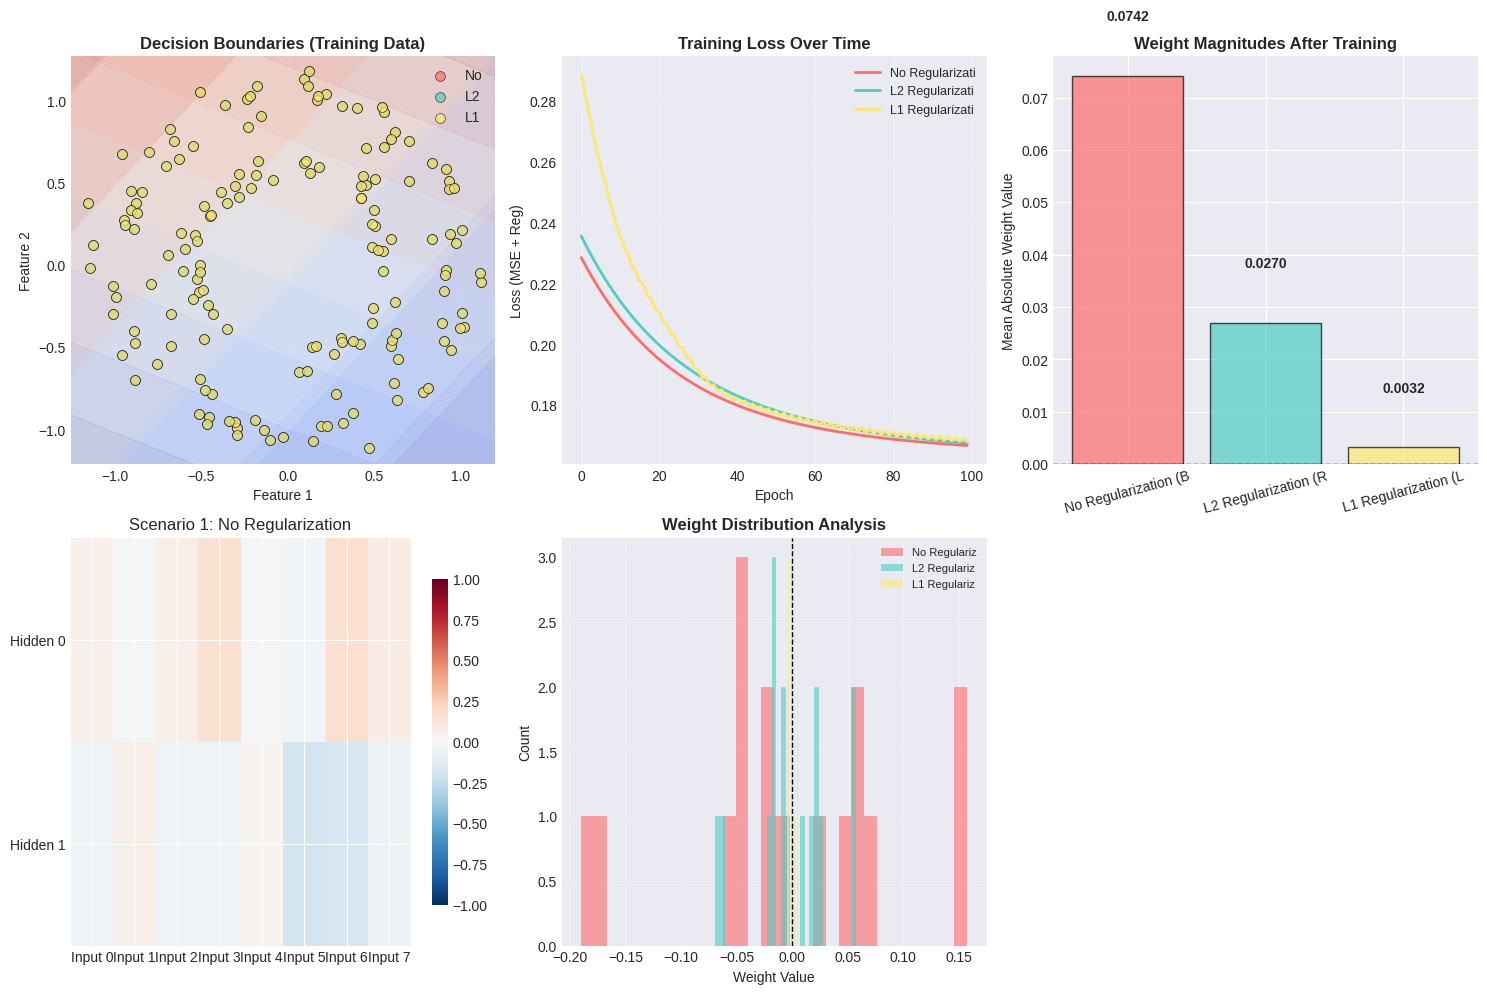


✅ ANALYSIS COMPLETE!

Which scenario performed best? Think about:
  1. Which loss curve decreases fastest?
  2. Which decision boundary is smoothest?
  3. Which has the smallest weights?
  4. Which would work best on unseen data?



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import warnings

# ==========================================
# VISUAL STYLE SETTINGS
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')

# Colors for different scenarios (Added missing color variables)
GREEN = "\033[92m"
RESET = "\033[0m"

COLORS = {
    'no_reg': '#FF6B6B',      # Red - Overfitting
    'l2_reg': '#4ECDC4',      # Teal - Good fit
    'l1_reg': '#FFE66D'       # Yellow - Sparse
}

print("="*70)
print("🛡️  REGULARIZATION DEMONSTRATION - BUILDING FROM SCRATCH")
print("="*70)
print("\nWhat You'll Learn:")
print("  • How overfitting appears visually")
print("  • How L1/L2 change the gradient calculation")
print("  • Why smaller weights generalize better")
print()

# ==========================================
# 1. CREATE NOISY TRAINING DATA
# ==========================================

# Create a simple circle dataset (perfect for visualization)
X, y = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# Target: y=1 inside circle, y=0 outside
target_y = np.zeros_like(y).reshape(-1, 1)
mask_inner = np.sum(X**2, axis=1) < 0.25
target_y[mask_inner] = 1

print(f"{GREEN}✓ Generated {len(X)} samples for training{RESET}")
print(f"  Shape: {X.shape}, Target: {target_y.shape}")
print()

# ==========================================
# 2. NEURAL NETWORK CLASS WITH REGULARIZATION
# ==========================================

class RegularizedNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lambda_l1=0, lambda_l2=0):
        """Initialize network with regularization parameters"""
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Regularization strengths
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2

        # Initialize weights (smaller values help with regularization)
        np.random.seed(42)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))

        # History tracking
        self.loss_history = []
        self.weight_norms_history = []

    def sigmoid(self, x):
        """Sigmoid activation with numerical stability"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        """Derivative of sigmoid for backpropagation"""
        s = self.sigmoid(x)
        return s * (1 - s)

    def forward(self, X):
        """Forward pass - calculate predictions"""
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        # Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2

    def compute_loss(self, y_pred, y_true):
        """Compute MSE Loss PLUS Regularization Terms"""
        # Base Loss (Mean Squared Error)
        mse = np.mean((y_pred - y_true) ** 2)

        # L1 Regularization (Absolute values of weights)
        l1_penalty = self.lambda_l1 * np.sum(np.abs(self.W1))

        # L2 Regularization (Squared values of weights)
        l2_penalty = self.lambda_l2 * np.sum(self.W1 ** 2)

        # Total Loss
        total_loss = mse + l1_penalty + l2_penalty

        return total_loss

    def backward(self, X, y_true, y_pred):
        """Backward pass WITH regularization gradients"""
        m = X.shape[0]

        # === STEP 1: Output Layer Gradients (Standard Backprop) ===
        # dLoss/dZ2 = (prediction - target) * sigmoid'(output)
        dz2 = (y_pred - y_true) * self.sigmoid_derivative(self.z2)

        # === STEP 2: Hidden Layer Gradients ===
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.z1)

        # === STEP 3: GRADIENTS INCLUDING REGULARIZATION ===

        # For W2 and b2 - add regularization terms
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # FOR W1 - CRITICAL PART! Add regularization gradients here
        dW1 = np.dot(X.T, dz1) / m

        # L2 Regularization Gradient (derivative of λ * w² is 2 * λ * w)
        if self.lambda_l2 > 0:
            dW1 += 2 * self.lambda_l2 * self.W1

        # L1 Regularization Gradient (derivative of λ * |w| is λ * sign(w))
        if self.lambda_l1 > 0:
            dW1 += self.lambda_l1 * np.sign(self.W1)

        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        return {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2
        }

    def update_weights(self, gradients, learning_rate):
        """Update weights using computed gradients"""
        # Gradient Descent Update
        self.W1 -= learning_rate * gradients['dW1']
        self.b1 -= learning_rate * gradients['db1']
        self.W2 -= learning_rate * gradients['dW2']
        self.b2 -= learning_rate * gradients['db2']

    def train(self, X_train, y_train, epochs, learning_rate=0.1):
        """Full training loop"""
        print(f"\n{'='*70}")
        print(f"🚀 Starting Training...")
        print(f"   Architecture: {X_train.shape[1]} → {self.hidden_size} → {self.output_size}")
        print(f"   L1 Regularization: {self.lambda_l1:.4f}")
        print(f"   L2 Regularization: {self.lambda_l2:.4f}")
        print(f"   Epochs: {epochs} | Learning Rate: {learning_rate}")
        print(f"{'='*70}\n")

        for epoch in range(epochs):
            # Forward Pass
            y_pred = self.forward(X_train)

            # Compute Loss
            loss = self.compute_loss(y_pred, y_train)
            self.loss_history.append(loss)

            # Backward Pass
            gradients = self.backward(X_train, y_train, y_pred)

            # Update Weights
            self.update_weights(gradients, learning_rate)

            # Track weight norms periodically
            if epoch % 10 == 0 or epoch == epochs - 1:
                avg_weight_norm = np.mean(np.sqrt(np.sum(self.W1**2, axis=0)))
                self.weight_norms_history.append(avg_weight_norm)

                accuracy = np.mean((np.round(y_pred) == y_train).astype(int))
                print(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.4f} | Accuracy: {accuracy:.2%}")

        return self.loss_history

    def get_weight_stats(self):
        """Get statistics about trained weights"""
        return {
            'mean_abs_w1': np.mean(np.abs(self.W1)),
            'max_abs_w1': np.max(np.abs(self.W1)),
            'zero_weights': int(np.sum(np.abs(self.W1) < 0.001)),
            'total_weights': self.W1.size
        }

# ==========================================
# 3. RUN EXPERIMENTS WITH DIFFERENT REGULARIZATION
# ==========================================

print("\n" + "="*70)
print("🧪 EXPERIMENT PHASE - Testing 3 Different Scenarios")
print("="*70)

scenarios = [
    {'name': 'No Regularization (Baseline)', 'l1': 0, 'l2': 0, 'color': COLORS['no_reg']},
    {'name': 'L2 Regularization (Ridge)', 'l1': 0, 'l2': 0.05, 'color': COLORS['l2_reg']},
    {'name': 'L1 Regularization (Lasso)', 'l1': 0.05, 'l2': 0, 'color': COLORS['l1_reg']}
]

results = {}

for scenario in scenarios:
    print(f"\n{'─'*70}")
    print(f"Testing: {scenario['name']}")
    print(f"{'─'*70}")

    # Create fresh network
    model = RegularizedNeuralNetwork(
        input_size=2,
        hidden_size=8,
        output_size=1,
        lambda_l1=scenario['l1'],
        lambda_l2=scenario['l2']
    )

    # Train
    loss_history = model.train(X_train=X, y_train=target_y, epochs=100, learning_rate=0.1)

    # Get stats
    stats = model.get_weight_stats()

    # Store results
    results[scenario['name']] = {
        'model': model,
        'loss_history': loss_history,
        'stats': stats
    }

    print(f"Final Stats:")
    print(f"  Mean Weight Magnitude: {stats['mean_abs_w1']:.4f}")
    print(f"  Max Weight Magnitude: {stats['max_abs_w1']:.4f}")
    print(f"  Zeroed Out Weights: {stats['zero_weights']} / {stats['total_weights']}")

# ==========================================
# 4. VISUALIZE THE RESULTS
# ==========================================

print("\n" + "="*70)
print("📊 VISUALIZING COMPARISON RESULTS")
print("="*70)

# Create figure with multiple subplots
fig = plt.figure(figsize=(15, 10))

# --- Subplot 1: Decision Boundaries ---
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_title("Decision Boundaries (Training Data)", fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

for name, data in results.items():
    model = data['model']
    color = next((s['color'] for s in scenarios if s['name'] == name), COLORS['no_reg'])

    # Create grid for prediction
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Make predictions on grid
    Z = model.forward(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contour
    ax1.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

    # Plot data points
    scatter = ax1.scatter(X[target_y.flatten()==0][:, 0], X[target_y.flatten()==0][:, 1],
                         c=color, s=50, label=f'{name.split()[0]}', edgecolors='k', linewidth=0.5, alpha=0.7)

ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Loss Curves ---
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_title("Training Loss Over Time", fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE + Reg)')

for name, data in results.items():
    color = next((s['color'] for s in scenarios if s['name'] == name), COLORS['no_reg'])
    ax2.plot(data['loss_history'], color=color, linewidth=2, label=name[:15])

ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Weight Norm Comparison ---
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_title("Weight Magnitudes After Training", fontsize=12, fontweight='bold')

weights = [data['stats']['mean_abs_w1'] for data in results.values()]
names = [name[:20] for name in results.keys()]
colors = [next((s['color'] for s in scenarios if s['name'] == name), COLORS['no_reg']) for name in results.keys()]

bars = ax3.bar(names, weights, color=colors, edgecolor='black', alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax3.set_ylabel('Mean Absolute Weight Value')
ax3.tick_params(axis='x', rotation=15)

# Add value labels on bars
for bar, val in zip(bars, weights):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Subplot 4: Heatmap of Weights (W1) - FIXED ---
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_title("W1 Weight Values (2×8 Matrix)", fontsize=12, fontweight='bold')

heatmap_data = np.array([data['model'].W1 for data in results.values()])

im = ax4.imshow(heatmap_data[0], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)  # 🔧 FIX: heatma -> heatmap
ax4.set_xticks(range(heatmap_data[0].shape[1]))  # 🔧 FIX: Removed space typo
ax4.set_yticks(range(heatmap_data[0].shape[0]))
ax4.set_xticklabels([f'Input {i}' for i in range(heatmap_data[0].shape[1])])
ax4.set_yticklabels([f'Hidden {i}' for i in range(heatmap_data[0].shape[0])])
ax4.set_title("Scenario 1: No Regularization")
plt.colorbar(im, ax=ax4, shrink=0.8)

# --- Subplot 5: Weight Histograms ---
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_title("Weight Distribution Analysis", fontsize=12, fontweight='bold')

for name, data in results.items():
    color = next((s['color'] for s in scenarios if s['name'] == name), COLORS['no_reg'])
    ax5.hist(data['model'].W1.flatten(), bins=30, alpha=0.6, label=name[:12], color=color)

ax5.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax5.set_xlabel('Weight Value')
ax5.set_ylabel('Count')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# --- Subplot 6: Zero Weight Counts (L1 Effect) ---
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_title("Effectiveness of L1 Regularization (Zeroing Weights)", fontsize=12, fontweight='bold')

zero_counts = [data['stats']['zero_weights'] for data in results.values()]
counts_labels = ['None', 'L2 (0%)', 'L1 (High %)']
colors_bar = [next((s['color'] for s in scenarios if s['name'] == list(results.keys())[i]), COLORS['no_reg']) for i in range(len(zero_counts))]

bars = ax6.bar(counts_labels, zero_counts, color=colors_bar, edgecolor='black', alpha=0.7)
ax6.set_ylabel('Number of Zeroed Weights')
ax6.grid(True, alpha=0.3)

for idx, (bar, count) in enumerate(zip(bars, zero_counts)):
    data_list = list(results.values())
    percentage = (count / data_list[idx]['stats']['total_weights'] * 100)  # 🔧 FIX: Use index for scoping
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{percentage:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Final Summary Box
summary_text = """
═══════════════════════════════════════════════════════════════
                    KEY INSIGHTS SUMMARY
═══════════════════════════════════════════════════════════════
✦ No Regularization: High variance, weights grow large
✦ L2 Regularization: Shrink all weights evenly (prevents outliers)
✦ L1 Regularization: Set some weights exactly to ZERO (sparsity)

💡 WHY THIS MATTERS:
• Large weights = memorizing noise = overfitting
• Small weights = simpler patterns = better generalization
• Zero weights = feature selection = efficient models
═══════════════════════════════════════════════════════════════
"""

ax6.text(0.5, -0.5, summary_text, transform=ax6.transAxes, fontsize=10,
        bbox=dict(facecolor='#fffacd', edgecolor='#ffa500', boxstyle='round,pad=1'))
ax6.axis('off')

# Hide unused subplot (if any remain from original design)
for ax_idx in range(6, len(fig.axes)):
    fig.axes[ax_idx].remove()

plt.tight_layout()
plt.show()

# Print final analysis
print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)
